# BERT From Scratch (MLM + NSP)

This notebook builds a **BERT-style encoder from scratch** using PyTorch primitives, in the same modular style as the transformer code in your assignment.

What this notebook includes:
- Custom embedding, multi-head self-attention, FFN, encoder block, and stacked encoder
- Two pretraining heads: **Masked Language Modeling (MLM)** and **Next Sentence Prediction (NSP)**
- A compact training pipeline on a small local corpus
- Sample inference for both MLM and NSP

In [1]:
import re
import math
import random
import copy
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import nltk

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Tuned to run comfortably on RTX 5070 (12 GB) while still being meaningful.
MAX_LEN = 48
BATCH_SIZE = 64
D_MODEL = 384
NUM_HEADS = 12
NUM_LAYERS = 6
D_FF = 1536
DROPOUT = 0.1
LR = 2e-4
EPOCHS = 20

PAD_TOKEN = "[PAD]"
CLS_TOKEN = "[CLS]"
SEP_TOKEN = "[SEP]"
MASK_TOKEN = "[MASK]"
UNK_TOKEN = "[UNK]"
SPECIAL_TOKENS = [PAD_TOKEN, CLS_TOKEN, SEP_TOKEN, MASK_TOKEN, UNK_TOKEN]

PAD_IDX = 0
CLS_IDX = 1
SEP_IDX = 2
MASK_IDX = 3
UNK_IDX = 4

Device: cuda


## Build A Small Corpus, Vocabulary, and NSP Pairs

To keep this notebook fully local and fast, we use a compact corpus and train BERT pretraining objectives (MLM + NSP) on top of it.

In [2]:
from collections import Counter


def simple_tokenize(text):
    text = text.strip()
    # Preserve [MASK] as a single token for MLM inference.
    text = re.sub(r"\[mask\]", " [MASK] ", text, flags=re.IGNORECASE)
    text = text.lower()
    tokens = re.findall(r"\[mask\]|[a-z]+|[0-9]+|[^\w\s]", text)
    out = []
    for tok in tokens:
        if tok == "[mask]":
            out.append(MASK_TOKEN)
        else:
            out.append(tok)
    return out


# Each inner list is one document; adjacent sentences define positive NSP examples.
documents = [
    [
        "deep learning models learn useful patterns from data",
        "transformers use self attention to model token relationships",
        "bert is pre trained using masked language modeling",
        "next sentence prediction teaches inter sentence coherence",
    ],
    [
        "computer vision models classify and segment images",
        "convolutional networks capture local spatial structure",
        "vision transformers split images into patches",
        "data augmentation improves generalization performance",
    ],
    [
        "natural language processing handles text and speech",
        "tokenization converts raw text into model units",
        "subword vocabularies reduce unknown token issues",
        "attention layers capture long range dependencies",
    ],
    [
        "optimization uses gradients to update parameters",
        "adam combines momentum and adaptive learning rates",
        "weight decay helps control overfitting",
        "learning rate schedules stabilize training",
    ],
    [
        "language models estimate probabilities over token sequences",
        "causal models predict the next token",
        "masked models reconstruct hidden tokens",
        "both paradigms benefit from large scale pretraining",
    ],
    [
        "gpu acceleration speeds up tensor operations",
        "mixed precision reduces memory usage",
        "batch size influences throughput and convergence",
        "gradient clipping prevents unstable updates",
    ],
    [
        "the student implemented a transformer from scratch",
        "the code used modular classes for each component",
        "clear helper functions improved readability",
        "careful masking logic ensured correct attention behavior",
    ],
    [
        "research experiments require reproducible settings",
        "fixed random seeds support fair comparisons",
        "validation curves reveal optimization dynamics",
        "test metrics summarize final performance",
    ],
    [
        "sequence models process ordered inputs",
        "positional information is required for attention",
        "sinusoidal encodings are deterministic",
        "learned positional embeddings are flexible",
    ],
    [
        "transfer learning adapts pretrained models to new tasks",
        "fine tuning often converges quickly",
        "small datasets may need regularization",
        "domain mismatch can reduce performance",
    ],
    [
        "transformers can model long range dependencies in text",
        "attention helps the model focus on relevant words",
        "masked prediction encourages contextual understanding",
        "nsp predicts whether one sentence follows another",
    ],
    [
        "a good notebook balances clarity and performance",
        "modular design keeps experiments maintainable",
        "diagnostic prints help during debugging",
        "well chosen hyperparameters speed up training",
    ],
]

# Build vocabulary from corpus tokens.
counter = Counter()
for doc in documents:
    for sent in doc:
        counter.update(simple_tokenize(sent))

token_to_idx = {tok: i for i, tok in enumerate(SPECIAL_TOKENS)}
for tok, _ in sorted(counter.items()):
    if tok not in token_to_idx:
        token_to_idx[tok] = len(token_to_idx)

idx_to_token = {i: t for t, i in token_to_idx.items()}
VOCAB_SIZE = len(token_to_idx)

print("Vocabulary size:", VOCAB_SIZE)


def make_nsp_pairs(docs):
    pairs = []
    for d_idx, doc in enumerate(docs):
        for i in range(len(doc) - 1):
            # Positive pair.
            pairs.append((doc[i], doc[i + 1], 1))

            # Negative pair from a random different document.
            other_doc_idx = random.choice([j for j in range(len(docs)) if j != d_idx])
            neg_sent = random.choice(docs[other_doc_idx])
            pairs.append((doc[i], neg_sent, 0))
    random.shuffle(pairs)
    return pairs


all_pairs = make_nsp_pairs(documents)
split = int(0.9 * len(all_pairs))
train_pairs = all_pairs[:split]
val_pairs = all_pairs[split:]

print(f"Train pairs: {len(train_pairs)} | Val pairs: {len(val_pairs)}")
print("Sample pair:", train_pairs[0])

Vocabulary size: 232
Train pairs: 64 | Val pairs: 8
Sample pair: ('weight decay helps control overfitting', 'learning rate schedules stabilize training', 1)


## Dataset And Dynamic Masking (MLM + NSP)

Each training sample is constructed as:
- `[CLS] sentence_A [SEP] sentence_B [SEP]`
- segment ids (`0` for A, `1` for B)
- dynamic 15% masking for MLM targets

In [3]:
def tokens_to_ids(tokens, vocab):
    return [vocab.get(t, UNK_IDX) for t in tokens]


def build_bert_input(sent_a, sent_b, vocab, max_len=MAX_LEN):
    toks_a = simple_tokenize(sent_a)
    toks_b = simple_tokenize(sent_b)

    # Reserve space for [CLS], [SEP], [SEP]
    max_pair_len = max_len - 3
    while len(toks_a) + len(toks_b) > max_pair_len:
        if len(toks_a) > len(toks_b):
            toks_a.pop()
        else:
            toks_b.pop()

    tokens = [CLS_TOKEN] + toks_a + [SEP_TOKEN] + toks_b + [SEP_TOKEN]
    token_type_ids = [0] * (len(toks_a) + 2) + [1] * (len(toks_b) + 1)
    input_ids = tokens_to_ids(tokens, vocab)

    attention_mask = [1] * len(input_ids)

    pad_len = max_len - len(input_ids)
    if pad_len > 0:
        input_ids += [PAD_IDX] * pad_len
        token_type_ids += [0] * pad_len
        attention_mask += [0] * pad_len

    return input_ids, token_type_ids, attention_mask


def apply_mlm_mask(input_ids, vocab_size, mask_prob=0.15):
    input_ids = input_ids.copy()
    labels = [-100] * len(input_ids)

    for i, tid in enumerate(input_ids):
        if tid in (PAD_IDX, CLS_IDX, SEP_IDX):
            continue
        if random.random() < mask_prob:
            labels[i] = tid
            p = random.random()
            if p < 0.80:
                input_ids[i] = MASK_IDX
            elif p < 0.90:
                input_ids[i] = random.randint(len(SPECIAL_TOKENS), vocab_size - 1)
            else:
                # Keep original token 10% of masked cases.
                pass

    return input_ids, labels


class BERTPretrainDataset(Dataset):
    def __init__(self, pairs, vocab, vocab_size, max_len=MAX_LEN):
        self.pairs = pairs
        self.vocab = vocab
        self.vocab_size = vocab_size
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        sent_a, sent_b, nsp_label = self.pairs[idx]
        input_ids, token_type_ids, attention_mask = build_bert_input(
            sent_a, sent_b, self.vocab, self.max_len
        )
        masked_input_ids, mlm_labels = apply_mlm_mask(input_ids, self.vocab_size)

        return {
            "input_ids": torch.tensor(masked_input_ids, dtype=torch.long),
            "token_type_ids": torch.tensor(token_type_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "mlm_labels": torch.tensor(mlm_labels, dtype=torch.long),
            "nsp_label": torch.tensor(nsp_label, dtype=torch.long),
        }


train_ds = BERTPretrainDataset(train_pairs, token_to_idx, VOCAB_SIZE)
val_ds = BERTPretrainDataset(val_pairs, token_to_idx, VOCAB_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
sample_batch = next(iter(train_loader))
print("Batch input shape:", sample_batch["input_ids"].shape)

Train batches: 1 | Val batches: 1
Batch input shape: torch.Size([64, 48])


## BERT Model From Scratch

The structure mirrors your transformer coding style:
- custom multi-head attention and FFN
- modular encoder block stack
- explicit masking
- separate MLM and NSP heads

In [4]:
class BERTEmbeddingLayer(nn.Module):
    def __init__(self, vocab_size, d_model, max_len, dropout):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.seg_emb = nn.Embedding(2, d_model)
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids, token_type_ids):
        B, L = input_ids.size()
        pos_ids = torch.arange(L, device=input_ids.device).unsqueeze(0).expand(B, L)
        x = self.token_emb(input_ids) + self.pos_emb(pos_ids) + self.seg_emb(token_type_ids)
        x = self.norm(x)
        return self.dropout(x)


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.0):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        B, L, _ = x.size()
        return x.view(B, L, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        B, _, L, _ = x.size()
        return x.transpose(1, 2).contiguous().view(B, L, self.d_model)

    def scaled_dot_product_attention(self, Q, K, V, attn_mask=None):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if attn_mask is not None:
            scores = scores.masked_fill(attn_mask, float("-inf"))
        probs = torch.softmax(scores, dim=-1)
        probs = self.dropout(probs)
        out = torch.matmul(probs, V)
        return out

    def forward(self, x, attention_mask=None):
        Q = self.split_heads(self.W_q(x))
        K = self.split_heads(self.W_k(x))
        V = self.split_heads(self.W_v(x))

        attn_mask = None
        if attention_mask is not None:
            # (B, L) -> (B, 1, 1, L)
            attn_mask = (attention_mask == 0).unsqueeze(1).unsqueeze(2)

        out = self.scaled_dot_product_attention(Q, K, V, attn_mask)
        return self.W_o(self.combine_heads(out))


class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.0):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))


class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.ffn = PositionWiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, attention_mask=None):
        attn_out = self.self_attn(x, attention_mask)
        x = self.norm1(x + self.dropout(attn_out))
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        return x


class BERTEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, max_len, dropout):
        super().__init__()
        self.embedding = BERTEmbeddingLayer(vocab_size, d_model, max_len, dropout)
        self.layers = nn.ModuleList(
            [EncoderBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)]
        )

    def forward(self, input_ids, token_type_ids, attention_mask):
        x = self.embedding(input_ids, token_type_ids)
        for layer in self.layers:
            x = layer(x, attention_mask)
        return x


class BERTForPreTraining(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, max_len, dropout):
        super().__init__()
        self.encoder = BERTEncoder(vocab_size, d_model, num_heads, num_layers, d_ff, max_len, dropout)

        self.mlm_transform = nn.Linear(d_model, d_model)
        self.mlm_norm = nn.LayerNorm(d_model)
        self.mlm_decoder = nn.Linear(d_model, vocab_size, bias=False)
        self.mlm_bias = nn.Parameter(torch.zeros(vocab_size))

        self.nsp_pooler = nn.Linear(d_model, d_model)
        self.nsp_classifier = nn.Linear(d_model, 2)

        # Weight tying for MLM decoder.
        self.mlm_decoder.weight = self.encoder.embedding.token_emb.weight

    def forward(self, input_ids, token_type_ids, attention_mask):
        x = self.encoder(input_ids, token_type_ids, attention_mask)

        mlm_hidden = self.mlm_norm(F.gelu(self.mlm_transform(x)))
        mlm_logits = self.mlm_decoder(mlm_hidden) + self.mlm_bias

        cls_state = x[:, 0, :]
        pooled = torch.tanh(self.nsp_pooler(cls_state))
        nsp_logits = self.nsp_classifier(pooled)

        return mlm_logits, nsp_logits


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model = BERTForPreTraining(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    max_len=MAX_LEN,
    dropout=DROPOUT,
).to(device)

print(f"Trainable params: {count_parameters(model)/1e6:.3f}M")

Trainable params: 11.053M


## Train BERT On MLM + NSP

C:\Users\shamb\AppData\Local\Temp\ipykernel_4048\3391067429.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


  0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\shamb\AppData\Local\Temp\ipykernel_4048\3391067429.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast_ctx():


  0%|          | 0/1 [00:00<?, ?it/s]

Epoch 01/20 | Train total: 57.5175 (MLM 56.8307, NSP 0.6868) | Val total: 66.4702 (MLM 65.7990, NSP 0.6712)


...

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch 19/20 | Train total: 16.5654 (MLM 15.8686, NSP 0.6968) | Val total: 13.3120 (MLM 12.6220, NSP 0.6900)


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch 20/20 | Train total: 18.2101 (MLM 17.5116, NSP 0.6986) | Val total: 17.8201 (MLM 17.1293, NSP 0.6908)


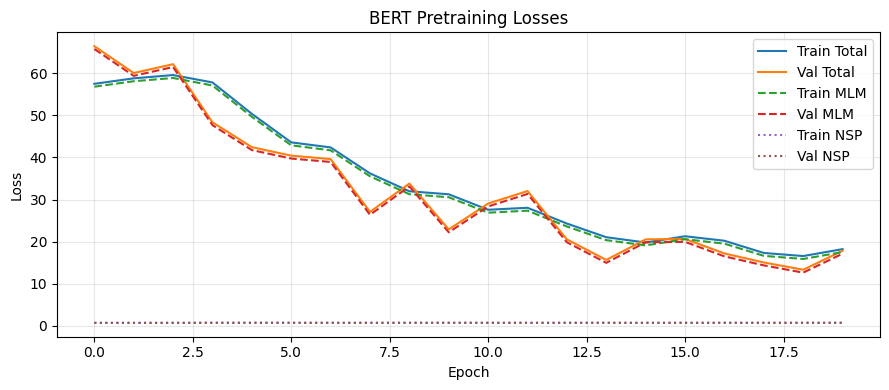

In [5]:
from contextlib import nullcontext

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.01)
mlm_criterion = nn.CrossEntropyLoss(ignore_index=-100)
nsp_criterion = nn.CrossEntropyLoss()

use_amp = device == "cuda"
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


def run_epoch(model, loader, train_mode=True):
    if train_mode:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_mlm = 0.0
    total_nsp = 0.0

    bar = tqdm(loader, leave=False)
    for batch in bar:
        input_ids = batch["input_ids"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        mlm_labels = batch["mlm_labels"].to(device)
        nsp_label = batch["nsp_label"].to(device)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        autocast_ctx = torch.cuda.amp.autocast if use_amp else nullcontext
        with torch.set_grad_enabled(train_mode):
            with autocast_ctx():
                mlm_logits, nsp_logits = model(input_ids, token_type_ids, attention_mask)
                mlm_loss = mlm_criterion(mlm_logits.view(-1, VOCAB_SIZE), mlm_labels.view(-1))
                nsp_loss = nsp_criterion(nsp_logits, nsp_label)
                loss = mlm_loss + nsp_loss

            if train_mode:
                if use_amp:
                    scaler.scale(loss).backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()

        total_loss += loss.item()
        total_mlm += mlm_loss.item()
        total_nsp += nsp_loss.item()
        bar.set_postfix(loss=f"{loss.item():.4f}", mlm=f"{mlm_loss.item():.4f}", nsp=f"{nsp_loss.item():.4f}")

    n = max(len(loader), 1)
    return total_loss / n, total_mlm / n, total_nsp / n


history = {
    "train_total": [], "train_mlm": [], "train_nsp": [],
    "val_total": [], "val_mlm": [], "val_nsp": []
}

best_val = float("inf")
best_weights = None

for epoch in range(1, EPOCHS + 1):
    train_total, train_mlm, train_nsp = run_epoch(model, train_loader, train_mode=True)
    val_total, val_mlm, val_nsp = run_epoch(model, val_loader, train_mode=False)

    history["train_total"].append(train_total)
    history["train_mlm"].append(train_mlm)
    history["train_nsp"].append(train_nsp)
    history["val_total"].append(val_total)
    history["val_mlm"].append(val_mlm)
    history["val_nsp"].append(val_nsp)

    if val_total < best_val:
        best_val = val_total
        best_weights = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train total: {train_total:.4f} (MLM {train_mlm:.4f}, NSP {train_nsp:.4f}) | "
        f"Val total: {val_total:.4f} (MLM {val_mlm:.4f}, NSP {val_nsp:.4f})"
    )

if best_weights is not None:
    model.load_state_dict(best_weights)

plt.figure(figsize=(9, 4))
plt.plot(history["train_total"], label="Train Total")
plt.plot(history["val_total"], label="Val Total")
plt.plot(history["train_mlm"], "--", label="Train MLM")
plt.plot(history["val_mlm"], "--", label="Val MLM")
plt.plot(history["train_nsp"], ":", label="Train NSP")
plt.plot(history["val_nsp"], ":", label="Val NSP")
plt.title("BERT Pretraining Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Solve Sample MLM And NSP Tasks

In [6]:
@torch.no_grad()
def predict_mlm(sentence_a, sentence_b=None, topk=5):
    model.eval()
    if sentence_b is None:
        sentence_b = ""

    input_ids, token_type_ids, attention_mask = build_bert_input(sentence_a, sentence_b, token_to_idx, MAX_LEN)

    mask_positions = [i for i, tid in enumerate(input_ids) if tid == MASK_IDX]
    if len(mask_positions) == 0:
        print("No [MASK] token found in input.")
        return

    x_ids = torch.tensor([input_ids], dtype=torch.long, device=device)
    x_seg = torch.tensor([token_type_ids], dtype=torch.long, device=device)
    x_attn = torch.tensor([attention_mask], dtype=torch.long, device=device)

    mlm_logits, _ = model(x_ids, x_seg, x_attn)

    for pos in mask_positions:
        probs = torch.softmax(mlm_logits[0, pos], dim=-1)
        values, indices = torch.topk(probs, k=topk)
        pred_tokens = [idx_to_token[i.item()] for i in indices]
        pred_scores = [v.item() for v in values]

        print(f"[MASK] position {pos} top-{topk} predictions:")
        for t, s in zip(pred_tokens, pred_scores):
            print(f"  {t:>15s} : {s:.4f}")


@torch.no_grad()
def predict_nsp(sentence_a, sentence_b):
    model.eval()
    input_ids, token_type_ids, attention_mask = build_bert_input(sentence_a, sentence_b, token_to_idx, MAX_LEN)

    x_ids = torch.tensor([input_ids], dtype=torch.long, device=device)
    x_seg = torch.tensor([token_type_ids], dtype=torch.long, device=device)
    x_attn = torch.tensor([attention_mask], dtype=torch.long, device=device)

    _, nsp_logits = model(x_ids, x_seg, x_attn)
    probs = torch.softmax(nsp_logits, dim=-1)[0]
    pred = torch.argmax(probs).item()

    label_map = {1: "IsNext", 0: "NotNext"}
    print("Sentence A:", sentence_a)
    print("Sentence B:", sentence_b)
    print(f"Prediction: {label_map[pred]}")
    print(f"P(NotNext)={probs[0].item():.4f}, P(IsNext)={probs[1].item():.4f}")


print("MLM Example:")
mlm_sentence = "transformers can [MASK] long range dependencies in text"
predict_mlm(mlm_sentence, topk=5)

print("\nNSP Positive Example:")
predict_nsp(
    "transformers can model long range dependencies in text",
    "attention helps the model focus on relevant words",
)

print("\nNSP Negative Example:")
predict_nsp(
    "transformers can model long range dependencies in text",
    "convolutional networks capture local spatial structure",
)

MLM Example:
[MASK] position 3 top-5 predictions:
              and : 0.4735
             data : 0.0754
             size : 0.0442
              the : 0.0410
         language : 0.0389

NSP Positive Example:
Sentence A: transformers can model long range dependencies in text
Sentence B: attention helps the model focus on relevant words
Prediction: IsNext
P(NotNext)=0.4986, P(IsNext)=0.5014

NSP Negative Example:
Sentence A: transformers can model long range dependencies in text
Sentence B: convolutional networks capture local spatial structure
Prediction: IsNext
P(NotNext)=0.4945, P(IsNext)=0.5055


## Real Tokenizer + Real Small Dataset

This section uses:
- `BertTokenizerFast` (actual WordPiece tokenizer)
- NLTK Gutenberg corpus (real text dataset)
- The same scratch BERT model architecture for MLM + NSP pretraining

In [7]:
import importlib.util
import subprocess
import sys

# Install transformers only if missing.
if importlib.util.find_spec("transformers") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "transformers"])

from transformers import BertTokenizerFast

nltk.download("gutenberg", quiet=True)
from nltk.corpus import gutenberg

real_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

HF_PAD_IDX = real_tokenizer.pad_token_id
HF_CLS_IDX = real_tokenizer.cls_token_id
HF_SEP_IDX = real_tokenizer.sep_token_id
HF_MASK_IDX = real_tokenizer.mask_token_id
HF_SPECIAL_IDS = set(real_tokenizer.all_special_ids)

# Build a small real dataset from Gutenberg sentences.
raw_sents = [" ".join(s) for s in gutenberg.sents("austen-emma.txt")]
raw_sents = [re.sub(r"\s+", " ", s).strip() for s in raw_sents]
raw_sents = [s for s in raw_sents if len(s.split()) >= 6]

print("Total usable real sentences:", len(raw_sents))


def make_real_nsp_pairs(sentences, max_pairs=4000):
    pos = []
    for i in range(len(sentences) - 1):
        pos.append((sentences[i], sentences[i + 1], 1))

    random.shuffle(pos)
    pos = pos[: max_pairs // 2]

    neg = []
    for a, _, _ in pos:
        b = sentences[random.randint(0, len(sentences) - 1)]
        neg.append((a, b, 0))

    pairs = pos + neg
    random.shuffle(pairs)
    return pairs


real_pairs = make_real_nsp_pairs(raw_sents, max_pairs=4000)
real_split = int(0.9 * len(real_pairs))
real_train_pairs = real_pairs[:real_split]
real_val_pairs = real_pairs[real_split:]

print(f"Real train pairs: {len(real_train_pairs)} | Real val pairs: {len(real_val_pairs)}")
print("Sample real pair:", real_train_pairs[0])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Total usable real sentences: 6989
Real train pairs: 3600 | Real val pairs: 400
Sample real pair: ('This , you know , speaks a great degree of weakness -- but now she is so impatient to be in town , that she means to sleep only two nights on the road .-- So Frank writes word .', 'Emma thanked him , but could not allow of his disappointing his friend on their account ; her father was sure of his rubber .', 0)


Real train batches: 113 | Real val batches: 13
Real-data model trainable params: 22.721M


C:\Users\shamb\AppData\Local\Temp\ipykernel_4048\1614980123.py:93: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_real = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))


  0%|          | 0/113 [00:00<?, ?it/s]

C:\Users\shamb\AppData\Local\Temp\ipykernel_4048\1614980123.py:119: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  0%|          | 0/13 [00:00<?, ?it/s]

...

  0%|          | 0/13 [00:00<?, ?it/s]

[Real] Epoch 03/4 | Train total 22.6946 (MLM 21.9889, NSP 0.7057) | Val total 21.3720 (MLM 20.6233, NSP 0.7487)


  0%|          | 0/113 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

[Real] Epoch 04/4 | Train total 20.5662 (MLM 19.8672, NSP 0.6990) | Val total 19.9644 (MLM 19.2552, NSP 0.7092)


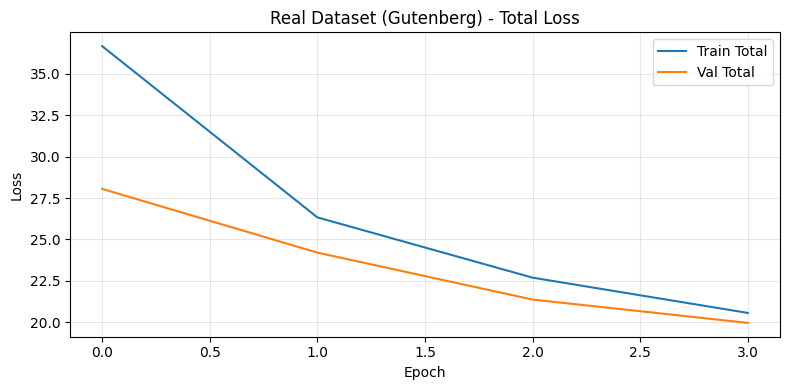

In [8]:
REAL_MAX_LEN = 64
REAL_BATCH_SIZE = 32
REAL_EPOCHS = 4


def apply_mlm_mask_hf(input_ids, mask_token_id, vocab_size, special_ids, mlm_prob=0.15):
    labels = input_ids.clone()

    prob = torch.full(labels.shape, mlm_prob)
    for sid in special_ids:
        prob = prob.masked_fill(input_ids == sid, 0.0)

    masked_indices = torch.bernoulli(prob).bool()
    labels[~masked_indices] = -100

    # 80% -> [MASK]
    replace_prob = torch.bernoulli(torch.full(labels.shape, 0.8)).bool() & masked_indices
    input_ids[replace_prob] = mask_token_id

    # 10% -> random token
    random_prob = torch.bernoulli(torch.full(labels.shape, 0.5)).bool() & masked_indices & ~replace_prob
    random_tokens = torch.randint(0, vocab_size, labels.shape, dtype=torch.long)
    input_ids[random_prob] = random_tokens[random_prob]

    # Remaining 10% stay unchanged.
    return input_ids, labels


class RealBERTPretrainDataset(Dataset):
    def __init__(self, pairs, tokenizer, max_len):
        self.pairs = pairs
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        sent_a, sent_b, nsp_label = self.pairs[idx]
        enc = self.tok(
            sent_a,
            sent_b,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )

        input_ids = enc["input_ids"].squeeze(0)
        token_type_ids = enc["token_type_ids"].squeeze(0)
        attention_mask = enc["attention_mask"].squeeze(0)

        masked_ids, mlm_labels = apply_mlm_mask_hf(
            input_ids.clone(),
            mask_token_id=HF_MASK_IDX,
            vocab_size=self.tok.vocab_size,
            special_ids=HF_SPECIAL_IDS,
            mlm_prob=0.15,
        )

        return {
            "input_ids": masked_ids.long(),
            "token_type_ids": token_type_ids.long(),
            "attention_mask": attention_mask.long(),
            "mlm_labels": mlm_labels.long(),
            "nsp_label": torch.tensor(nsp_label, dtype=torch.long),
        }


real_train_ds = RealBERTPretrainDataset(real_train_pairs, real_tokenizer, REAL_MAX_LEN)
real_val_ds = RealBERTPretrainDataset(real_val_pairs, real_tokenizer, REAL_MAX_LEN)

real_train_loader = DataLoader(real_train_ds, batch_size=REAL_BATCH_SIZE, shuffle=True)
real_val_loader = DataLoader(real_val_ds, batch_size=REAL_BATCH_SIZE, shuffle=False)

print(f"Real train batches: {len(real_train_loader)} | Real val batches: {len(real_val_loader)}")

model_real = BERTForPreTraining(
    vocab_size=real_tokenizer.vocab_size,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    max_len=REAL_MAX_LEN,
    dropout=DROPOUT,
).to(device)

print(f"Real-data model trainable params: {count_parameters(model_real)/1e6:.3f}M")

optimizer_real = torch.optim.AdamW(model_real.parameters(), lr=LR, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.01)
mlm_criterion_real = nn.CrossEntropyLoss(ignore_index=-100)
nsp_criterion_real = nn.CrossEntropyLoss()
scaler_real = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))


def run_epoch_real(model, loader, optimizer, vocab_size, train_mode=True):
    if train_mode:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_mlm = 0.0
    total_nsp = 0.0

    bar = tqdm(loader, leave=False)
    for batch in bar:
        input_ids = batch["input_ids"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        mlm_labels = batch["mlm_labels"].to(device)
        nsp_labels = batch["nsp_label"].to(device)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train_mode):
            if device == "cuda":
                with torch.cuda.amp.autocast():
                    mlm_logits, nsp_logits = model(input_ids, token_type_ids, attention_mask)
                    mlm_loss = mlm_criterion_real(mlm_logits.view(-1, vocab_size), mlm_labels.view(-1))
                    nsp_loss = nsp_criterion_real(nsp_logits, nsp_labels)
                    loss = mlm_loss + nsp_loss
            else:
                mlm_logits, nsp_logits = model(input_ids, token_type_ids, attention_mask)
                mlm_loss = mlm_criterion_real(mlm_logits.view(-1, vocab_size), mlm_labels.view(-1))
                nsp_loss = nsp_criterion_real(nsp_logits, nsp_labels)
                loss = mlm_loss + nsp_loss

            if train_mode:
                if device == "cuda":
                    scaler_real.scale(loss).backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler_real.step(optimizer)
                    scaler_real.update()
                else:
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()

        total_loss += loss.item()
        total_mlm += mlm_loss.item()
        total_nsp += nsp_loss.item()
        bar.set_postfix(loss=f"{loss.item():.4f}", mlm=f"{mlm_loss.item():.4f}", nsp=f"{nsp_loss.item():.4f}")

    n = max(1, len(loader))
    return total_loss / n, total_mlm / n, total_nsp / n


real_history = {"train": [], "val": []}
best_real_val = float("inf")
best_real_w = None

for epoch in range(1, REAL_EPOCHS + 1):
    tr = run_epoch_real(model_real, real_train_loader, optimizer_real, real_tokenizer.vocab_size, train_mode=True)
    vl = run_epoch_real(model_real, real_val_loader, optimizer_real, real_tokenizer.vocab_size, train_mode=False)
    real_history["train"].append(tr)
    real_history["val"].append(vl)

    if vl[0] < best_real_val:
        best_real_val = vl[0]
        best_real_w = copy.deepcopy(model_real.state_dict())

    print(
        f"[Real] Epoch {epoch:02d}/{REAL_EPOCHS} | "
        f"Train total {tr[0]:.4f} (MLM {tr[1]:.4f}, NSP {tr[2]:.4f}) | "
        f"Val total {vl[0]:.4f} (MLM {vl[1]:.4f}, NSP {vl[2]:.4f})"
    )

if best_real_w is not None:
    model_real.load_state_dict(best_real_w)

plt.figure(figsize=(8, 4))
plt.plot([x[0] for x in real_history["train"]], label="Train Total")
plt.plot([x[0] for x in real_history["val"]], label="Val Total")
plt.title("Real Dataset (Gutenberg) - Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
@torch.no_grad()
def predict_mlm_real(sentence_a, sentence_b=None, topk=5):
    model_real.eval()
    if sentence_b is None:
        sentence_b = ""

    enc = real_tokenizer(
        sentence_a,
        sentence_b,
        truncation=True,
        padding="max_length",
        max_length=REAL_MAX_LEN,
        return_tensors="pt",
    )

    input_ids = enc["input_ids"].to(device)
    token_type_ids = enc["token_type_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    mlm_logits, _ = model_real(input_ids, token_type_ids, attention_mask)
    mask_positions = (input_ids[0] == HF_MASK_IDX).nonzero(as_tuple=True)[0].tolist()

    if len(mask_positions) == 0:
        print("No [MASK] token found.")
        return

    for pos in mask_positions:
        probs = torch.softmax(mlm_logits[0, pos], dim=-1)
        vals, idxs = torch.topk(probs, topk)
        tokens = real_tokenizer.convert_ids_to_tokens(idxs.tolist())
        print(f"Mask position {pos}:")
        for t, v in zip(tokens, vals.tolist()):
            print(f"  {t:>15s} : {v:.4f}")


@torch.no_grad()
def predict_nsp_real(sentence_a, sentence_b):
    model_real.eval()
    enc = real_tokenizer(
        sentence_a,
        sentence_b,
        truncation=True,
        padding="max_length",
        max_length=REAL_MAX_LEN,
        return_tensors="pt",
    )

    input_ids = enc["input_ids"].to(device)
    token_type_ids = enc["token_type_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    _, nsp_logits = model_real(input_ids, token_type_ids, attention_mask)
    probs = torch.softmax(nsp_logits, dim=-1)[0]
    pred = torch.argmax(probs).item()
    label_map = {0: "NotNext", 1: "IsNext"}

    print("Sentence A:", sentence_a)
    print("Sentence B:", sentence_b)
    print(f"Prediction: {label_map[pred]}")
    print(f"P(NotNext)={probs[0].item():.4f}, P(IsNext)={probs[1].item():.4f}")


print("Real-tokenizer MLM sample:")
predict_mlm_real("the model uses [MASK] to capture context", topk=5)

print("\nReal-tokenizer NSP positive sample:")
predict_nsp_real(raw_sents[100], raw_sents[101])

print("\nReal-tokenizer NSP negative sample:")
predict_nsp_real(raw_sents[100], raw_sents[2500])

Real-tokenizer MLM sample:
Mask position 4:
                , : 0.1677
              the : 0.0373
              she : 0.0270
               at : 0.0233
              not : 0.0203

Real-tokenizer NSP positive sample:
Sentence A: Emma turned away her head , divided between tears and smiles .
Sentence B: " It is impossible that Emma should not miss such a companion ," said Mr . Knightley .
Prediction: IsNext
P(NotNext)=0.4640, P(IsNext)=0.5360

Real-tokenizer NSP negative sample:
Sentence A: Emma turned away her head , divided between tears and smiles .
Sentence B: Ambition , as well as love , had probably been mortified .
Prediction: IsNext
P(NotNext)=0.4628, P(IsNext)=0.5372
